# HOMEWORK 12 (lesson 13)

This assignment focuses on the analysis of the `GTSRB` (German Traffic Sign Recognition Benchmark) `Train.csv` dataset, which contains images of various traffic sign classes used in Germany and across the EU. 

The objective is to perform exploratory data analysis (EDA) to examine key dataset characteristics and identify potential challenges for training machine learning models. Particular attention is given to class distribution, image resolution, and brightness properties in order to understand data variability and quality.

In [180]:
import os
import cv2
import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Visual Analysis

Random samples from the dataset are displayed to perform a qualitative visual analysis.

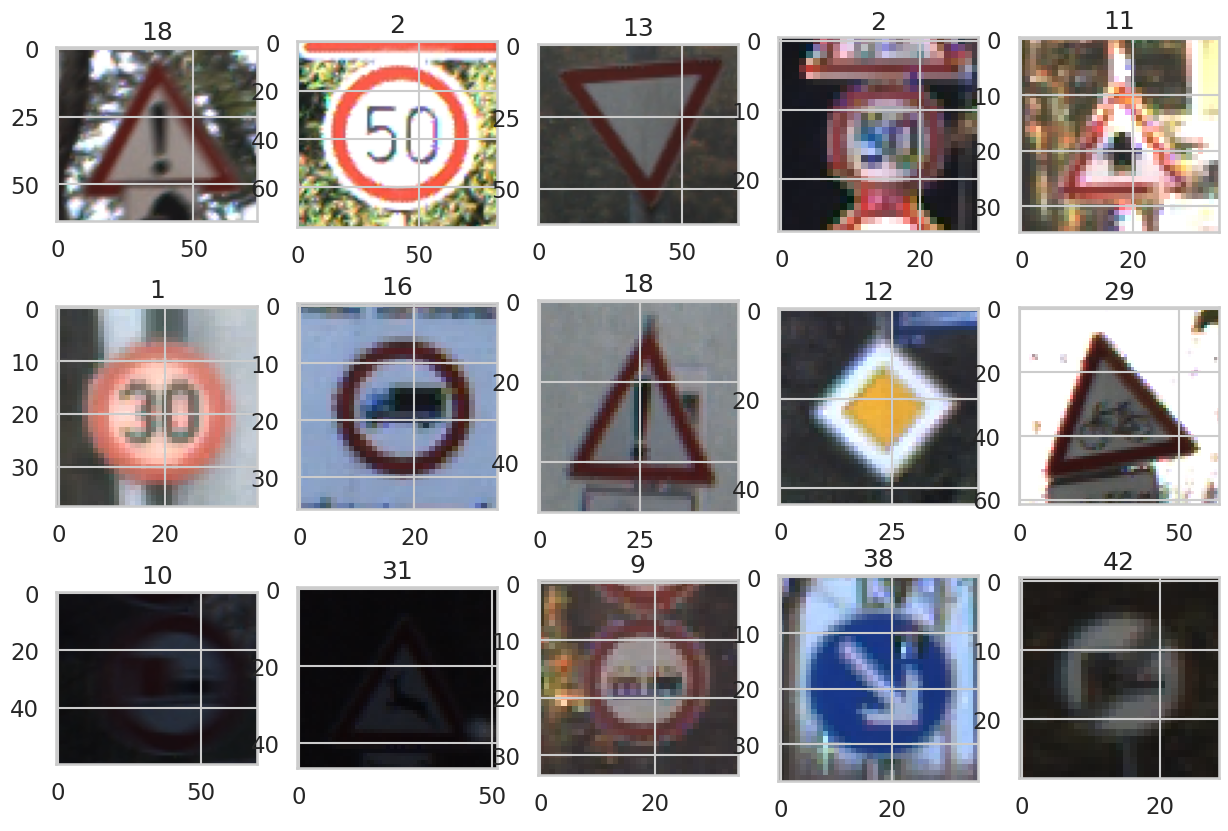

In [181]:
root = '/home/olena-yazykova/computer_vision/lesson_13/data/GTSRB'
data = pd.read_csv(os.path.join(root, 'Train.csv'))

num_samples = len(data)

for ii in range(15):
    idx = np.random.randint(0, num_samples)

    img = cv2.imread(os.path.join(root, data.iloc[idx]['Path']))

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,5,ii+1), plt.imshow(img), plt.title(data.iloc[idx]['ClassId'])

The visual inspection of randomly sampled images reveals significant variability in image quality, size, illumination, and background conditions. Many images are small and slightly blurred, which may increase the difficulty of classification.

There is also noticeable variation in brightness, ranging from dark to highly illuminated images, suggesting that lighting conditions are not controlled. Backgrounds are often complex and may include noise or partial occlusions.

Overall, the dataset reflects real-world conditions, where traffic signs appear at different scales, orientations, and lighting environments, while still preserving their distinctive shapes and patterns.

In [182]:
# Label Overview
classes = { 0:'Speed limit (20km/h)',
            1:'Speed limit (30km/h)', 
            2:'Speed limit (50km/h)', 
            3:'Speed limit (60km/h)', 
            4:'Speed limit (70km/h)', 
            5:'Speed limit (80km/h)', 
            6:'End of speed limit (80km/h)', 
            7:'Speed limit (100km/h)', 
            8:'Speed limit (120km/h)', 
            9:'No passing', 
            10:'No passing veh over 3.5 tons', 
            11:'Right-of-way at intersection', 
            12:'Priority road', 
            13:'Yield', 
            14:'Stop', 
            15:'No vehicles', 
            16:'Veh > 3.5 tons prohibited', 
            17:'No entry', 
            18:'General caution', 
            19:'Dangerous curve left', 
            20:'Dangerous curve right', 
            21:'Double curve', 
            22:'Bumpy road', 
            23:'Slippery road', 
            24:'Road narrows on the right', 
            25:'Road work', 
            26:'Traffic signals', 
            27:'Pedestrians', 
            28:'Children crossing', 
            29:'Bicycles crossing', 
            30:'Beware of ice/snow',
            31:'Wild animals crossing', 
            32:'End speed + passing limits', 
            33:'Turn right ahead', 
            34:'Turn left ahead', 
            35:'Ahead only', 
            36:'Go straight or right', 
            37:'Go straight or left', 
            38:'Keep right', 
            39:'Keep left', 
            40:'Roundabout mandatory', 
            41:'End of no passing', 
            42:'End no passing veh > 3.5 tons' }

# Class Distribution and Balance Analysis

The class distribution is analyzed by computing the number of samples per class and visualizing the results using a bar plot, which allows assessing dataset balance.

In [183]:
def plot_class_distribution(data, classes):

    # Compute class counts
    class_counts = data['ClassId'].value_counts()
    class_counts = class_counts.sort_values(ascending=False)

    # Map class IDs to class names
    class_names = [classes[i] for i in class_counts.index]

    # Create a DataFrame for plotting
    plot_df = pd.DataFrame({
        'ClassName': class_names,
        'Count': class_counts.values
    })

    # Create color mapping based on counts
    norm = plt.Normalize(plot_df['Count'].min(), plot_df['Count'].max())
    colors = plt.cm.viridis(norm(plot_df['Count']))

    # Plot bar chart
    plt.figure(figsize=(22,10))

    ax = sns.barplot(
        x='ClassName',
        y='Count',
        data=plot_df,
        hue='ClassName',
        dodge=False,
        palette=colors,
        legend=False
    )

    # Axis labels and title
    plt.xlabel('Traffic Sign Class')
    plt.ylabel('Number of Images')
    plt.title('Class Distribution in GTSRB (sorted)')

    # Rotate x-axis labels for readability
    plt.xticks(rotation=90)

    # Add value labels above bars
    for i, v in enumerate(plot_df['Count']):
        ax.text(i, v + 20, str(v), ha='center', fontsize=8)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_97388/1809781851.py:23: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  ax = sns.barplot(


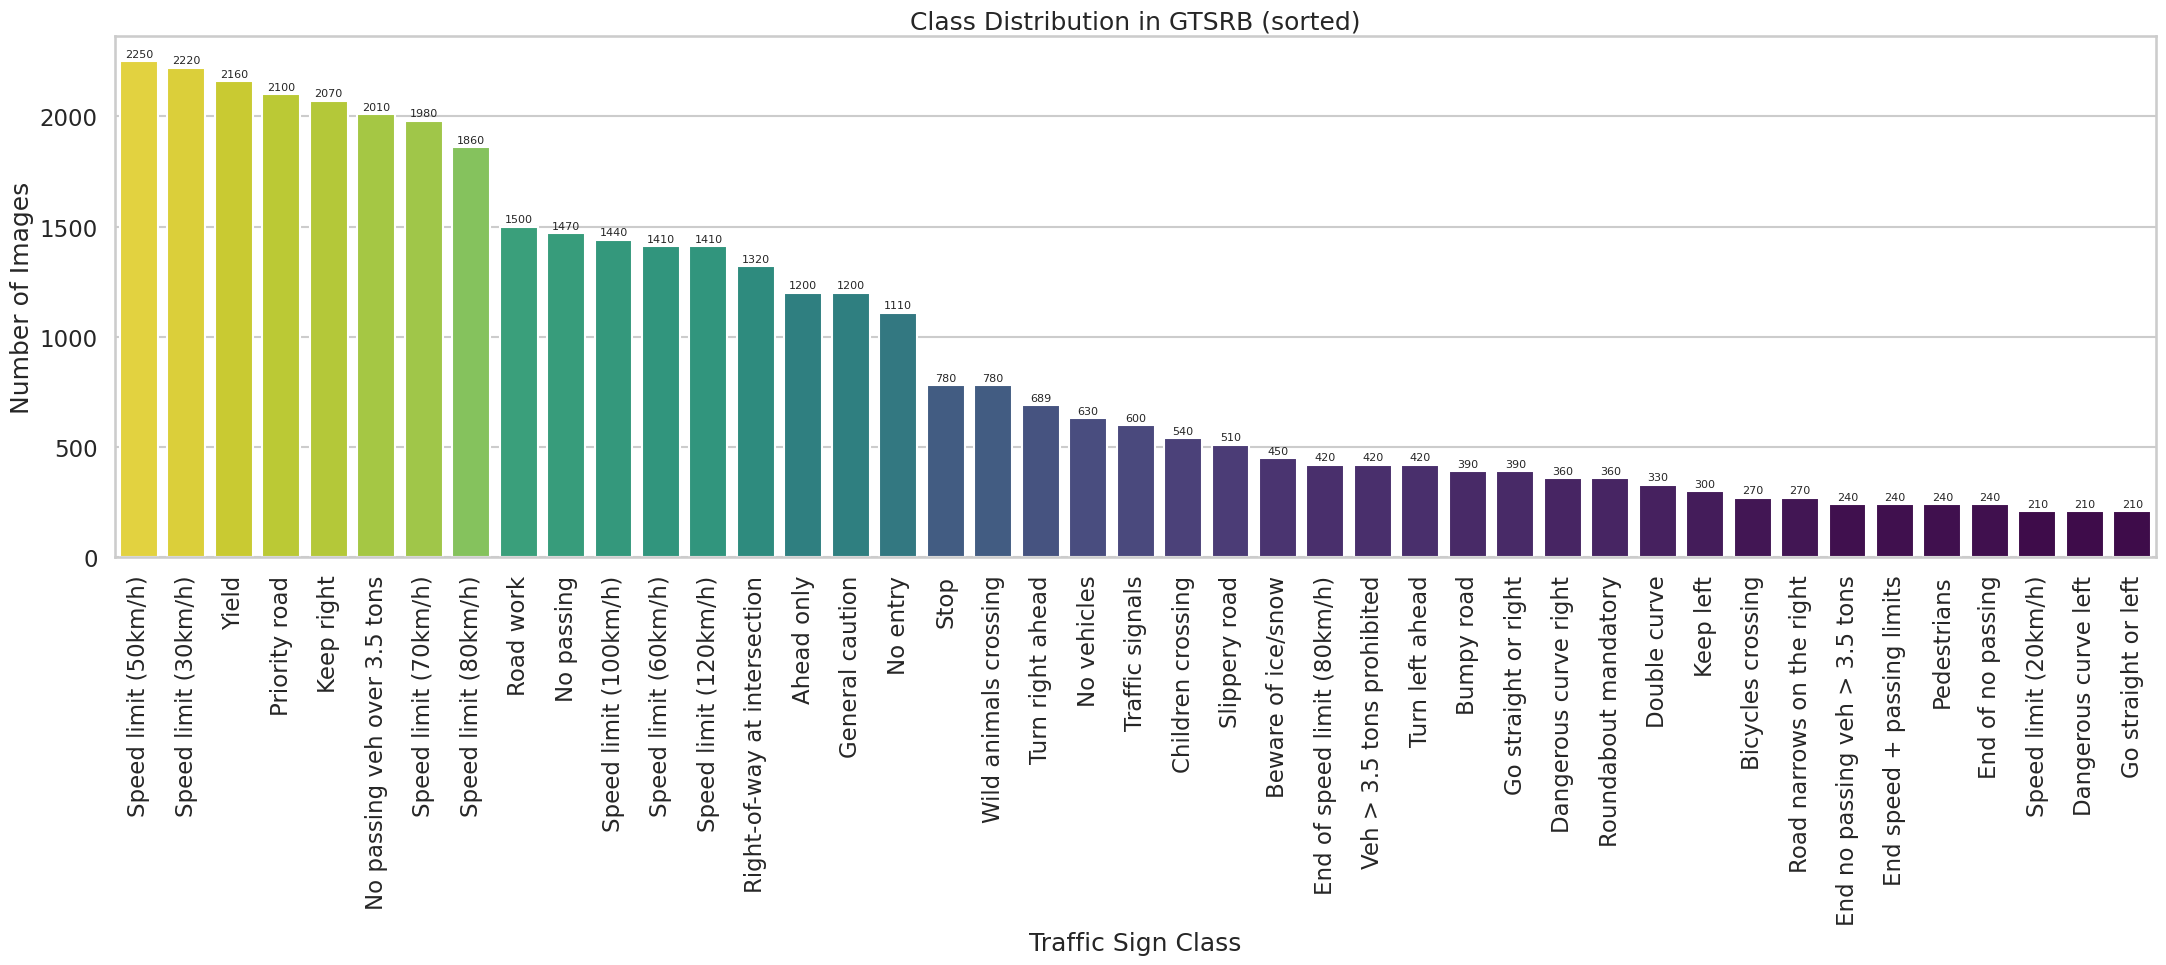

In [184]:
plot_class_distribution(data, classes)

In [186]:
def compute_class_stats(data):
    class_counts = data['ClassId'].value_counts()
    
    return class_counts.describe()

compute_class_stats(data)

count      43.000000
mean      911.837209
std       695.856715
min       210.000000
25%       345.000000
50%       600.000000
75%      1425.000000
max      2250.000000
Name: count, dtype: float64

**Is the dataset balanced?**

The dataset is not balanced.

The number of images per class varies significantly, ranging from 210 to 2250 samples per class, with a mean of approximately 912 and a high standard deviation of about 696. This large variation indicates an uneven distribution of data across classes.

**Are there over-represented or under-represented classes?**

Yes, there are clear differences:

Over-represented classes:
Some classes (e.g., speed limit signs like 30 km/h, 50 km/h, and priority road) contain more than 2000 images, making them dominant in the dataset.

Under-represented classes:
Other classes (e.g., rare signs like “Go straight or left”, “Dangerous curve left”, etc.) contain as few as ~200–300 images.

# Image Size and Aspect Ratio Analysis

In [187]:
data['Area'] = data['Width'] * data['Height']

In [232]:
def plot_resolution_analysis(data):
    import matplotlib.pyplot as plt
    import seaborn as sns

    sns.set_style("whitegrid")

    widths = data['Width']
    heights = data['Height']
    area = widths * heights
    aspect_ratio = widths / heights

    plt.figure(figsize=(14,10))

    c_width = "#4C72B0"
    c_height = "#DD8452"
    c_scatter = "#55A868"
    c_area = "#8172B2"
    c_ratio = "#937860"

    # 1. Width & Height
    plt.subplot(2,2,1)
    plt.hist(widths, bins=30, alpha=0.6, label='Width', color=c_width)
    plt.hist(heights, bins=30, alpha=0.6, label='Height', color=c_height)
    plt.legend()
    plt.title('Width & Height Distribution')

    # 2. Scatter
    plt.subplot(2,2,2)
    sns.scatterplot(x=widths, y=heights, alpha=0.3, color=c_scatter)
    plt.xlabel('Width')
    plt.ylabel('Height')
    plt.title('Width vs Height')

    # 3. Area
    plt.subplot(2,2,3)
    sns.histplot(area, bins=30, color=c_area)
    plt.xlabel('Area (pixels²)')
    plt.title('Image Area Distribution')

    # 4. Aspect Ratio
    plt.subplot(2,2,4)
    sns.histplot(aspect_ratio, bins=30, color=c_ratio)
    plt.xlabel('Aspect Ratio (Width / Height)')
    plt.title('Aspect Ratio Distribution')

    plt.tight_layout()
    plt.show()

def plot_area_boxplot(data, classes):
    import matplotlib.pyplot as plt
    import seaborn as sns

    data = data.copy()
    data['Area'] = data['Width'] * data['Height']
    data['ClassName'] = data['ClassId'].apply(lambda x: classes[x])

    lower = data['Area'].quantile(0.01)
    upper = data['Area'].quantile(0.99)
    data_clipped = data[(data['Area'] >= lower) & (data['Area'] <= upper)]

    plt.figure(figsize=(24,12))

    palette = sns.color_palette("husl", len(classes))

    sns.boxplot(
        x='ClassName',
        y='Area',
        data=data_clipped,
        hue='ClassName',
        palette=palette,
        dodge=False,
        legend=False
    )

    plt.xticks(rotation=90)
    plt.xlabel('')
    plt.ylabel('Area (pixels²)')
    plt.title('Image Area per Class (Boxplot)')

    plt.tight_layout()
    plt.show()

def plot_resolution_per_class_grid(data, classes, n_cols=5):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    data = data.copy()
    data['Area'] = data['Width'] * data['Height']

    class_ids = sorted(data['ClassId'].unique())
    n_classes = len(class_ids)
    n_rows = int(np.ceil(n_classes / n_cols))

    palette = sns.color_palette("husl", n_classes)

    plt.figure(figsize=(20, n_rows * 3))

    plt.suptitle('Distribution of Image Area per Class', fontsize=20, y=1.01)

    for i, cid in enumerate(class_ids):
        plt.subplot(n_rows, n_cols, i+1)

        subset = data[data['ClassId'] == cid]

        sns.histplot(
            subset['Area'],
            bins=20,
            color=palette[i]
        )

        plt.title(classes[cid][:20], fontsize=12)

        plt.xticks(fontsize=8)
        plt.yticks(fontsize=8)

        plt.xlabel('')
        plt.ylabel('')

    plt.tight_layout()
    plt.show()

def resolution_stats(data, classes):
    import pandas as pd

    df = data.copy()
    df['Area'] = df['Width'] * df['Height']

    stats = df.groupby('ClassId').agg({
        'Width': ['mean', 'std'],
        'Height': ['mean', 'std'],
        'Area': ['mean', 'std']
    })

    stats.columns = [
        'Width_mean', 'Width_std',
        'Height_mean', 'Height_std',
        'Area_mean', 'Area_std'
    ]

    stats['ClassName'] = stats.index.map(lambda x: classes[x])

    stats = stats.sort_values(by='Area_mean', ascending=False)

    return stats

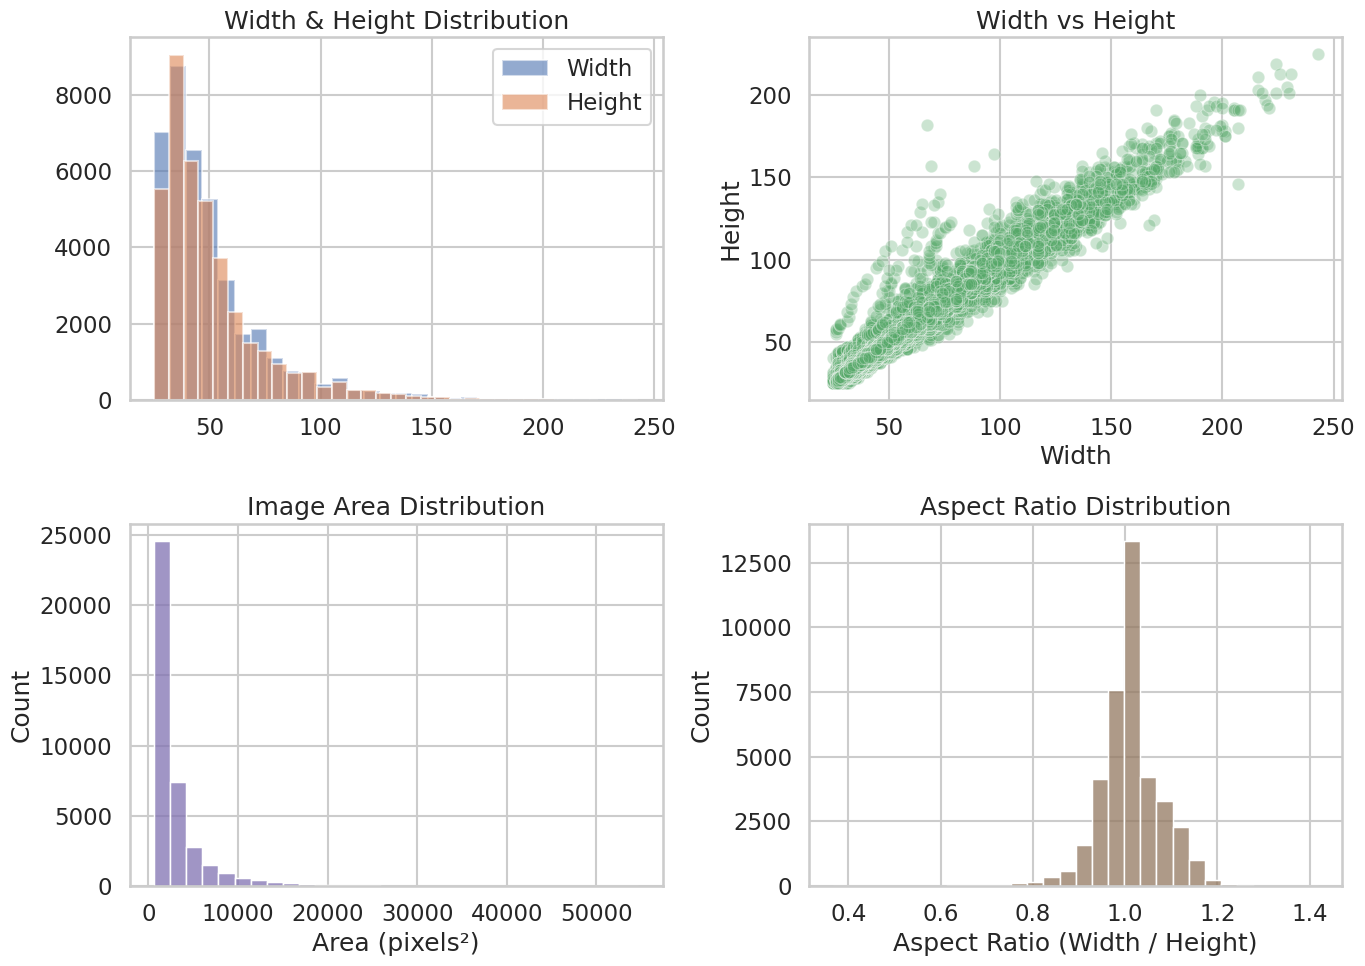

In [233]:
plot_resolution_analysis(data)

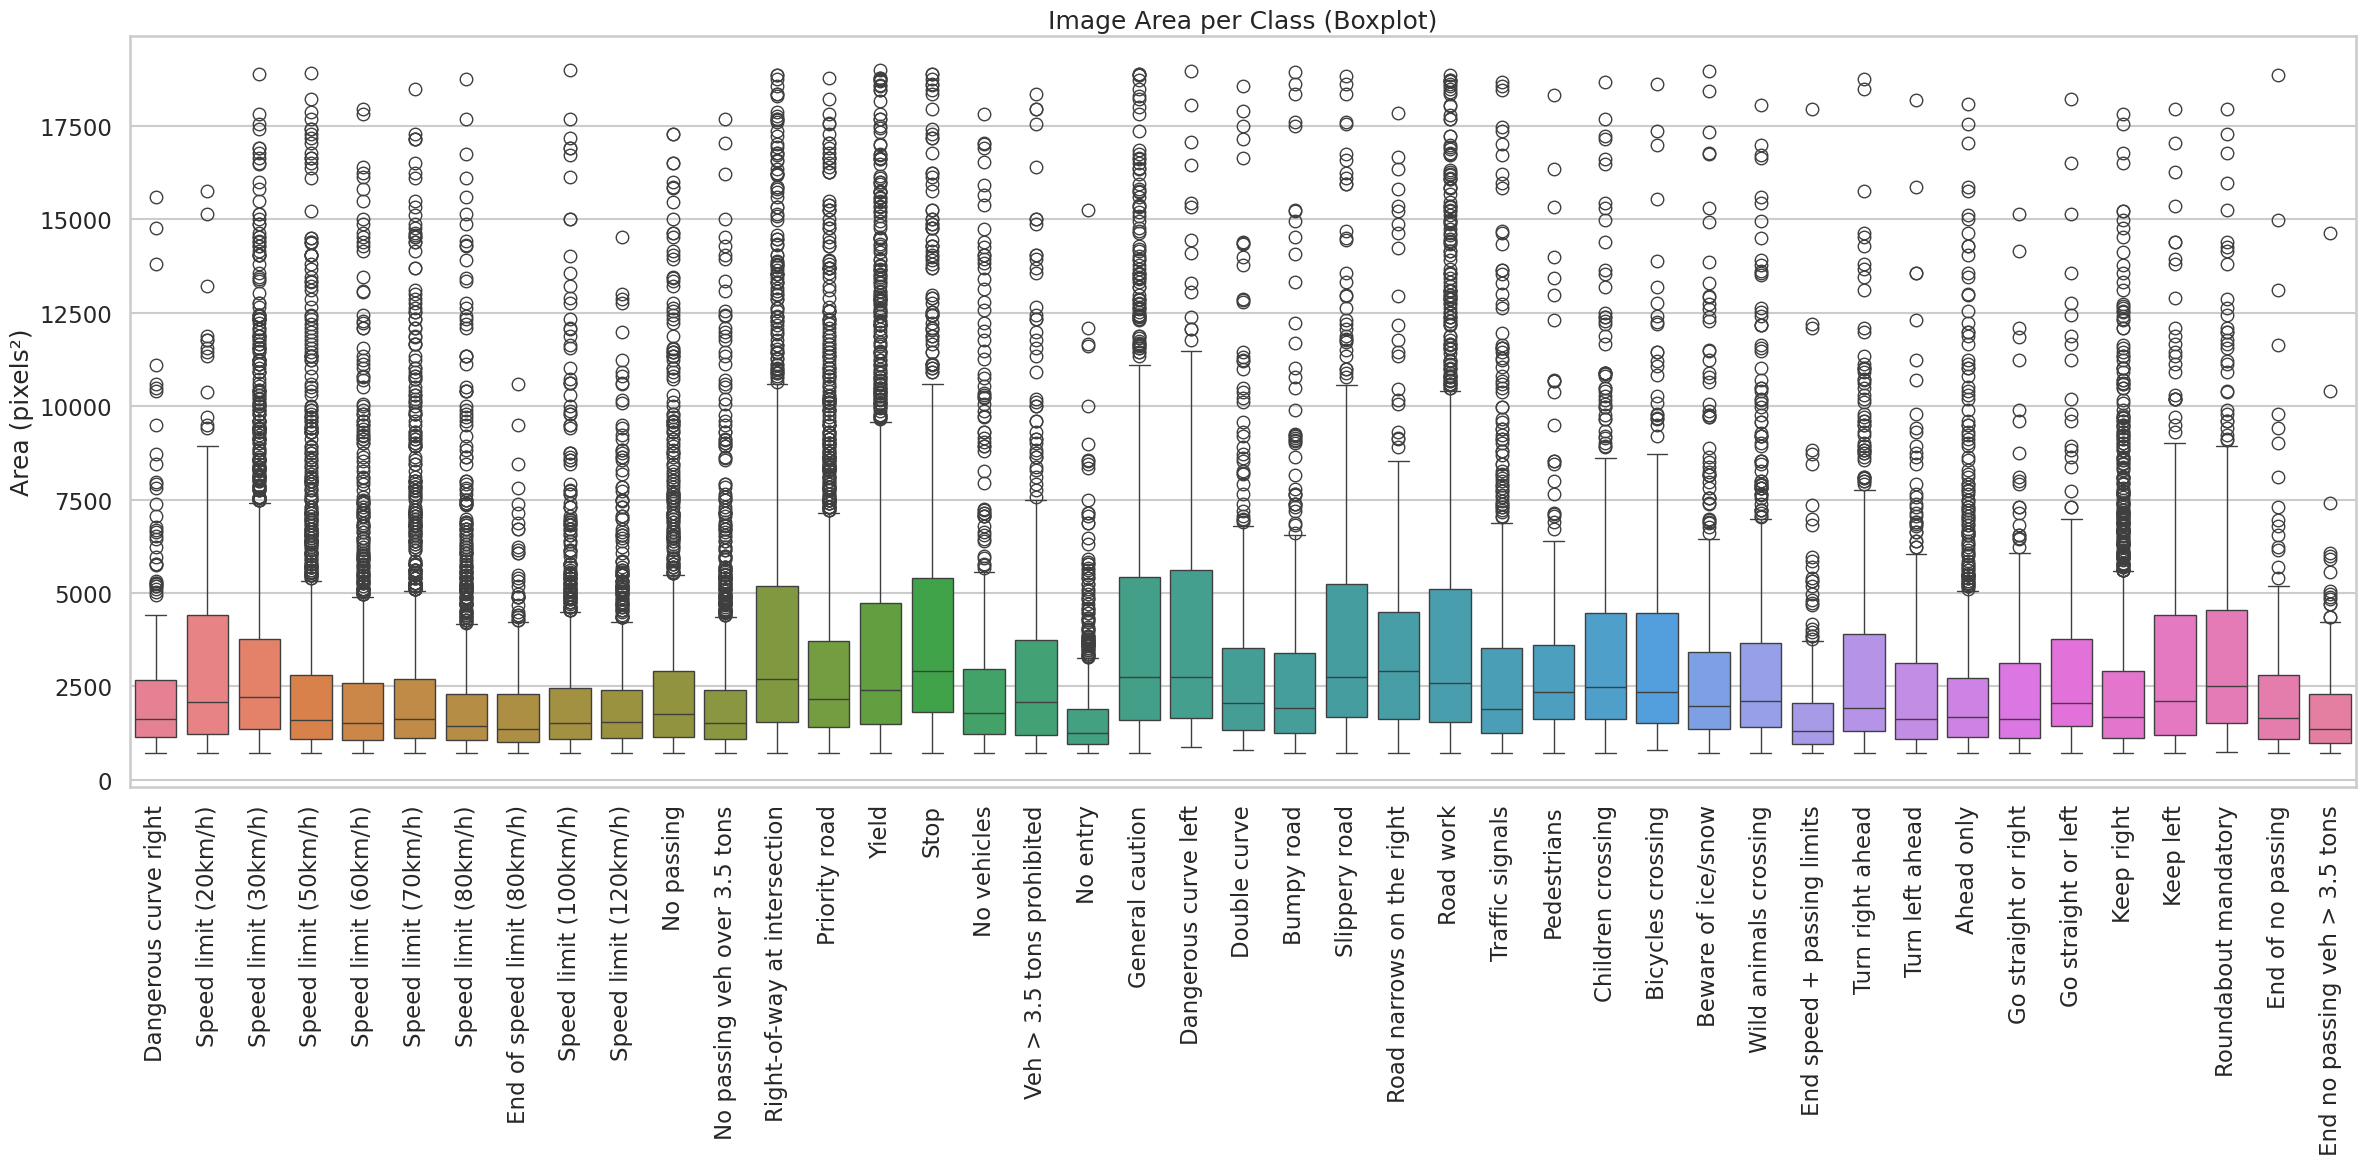

In [234]:
plot_area_boxplot(data, classes)

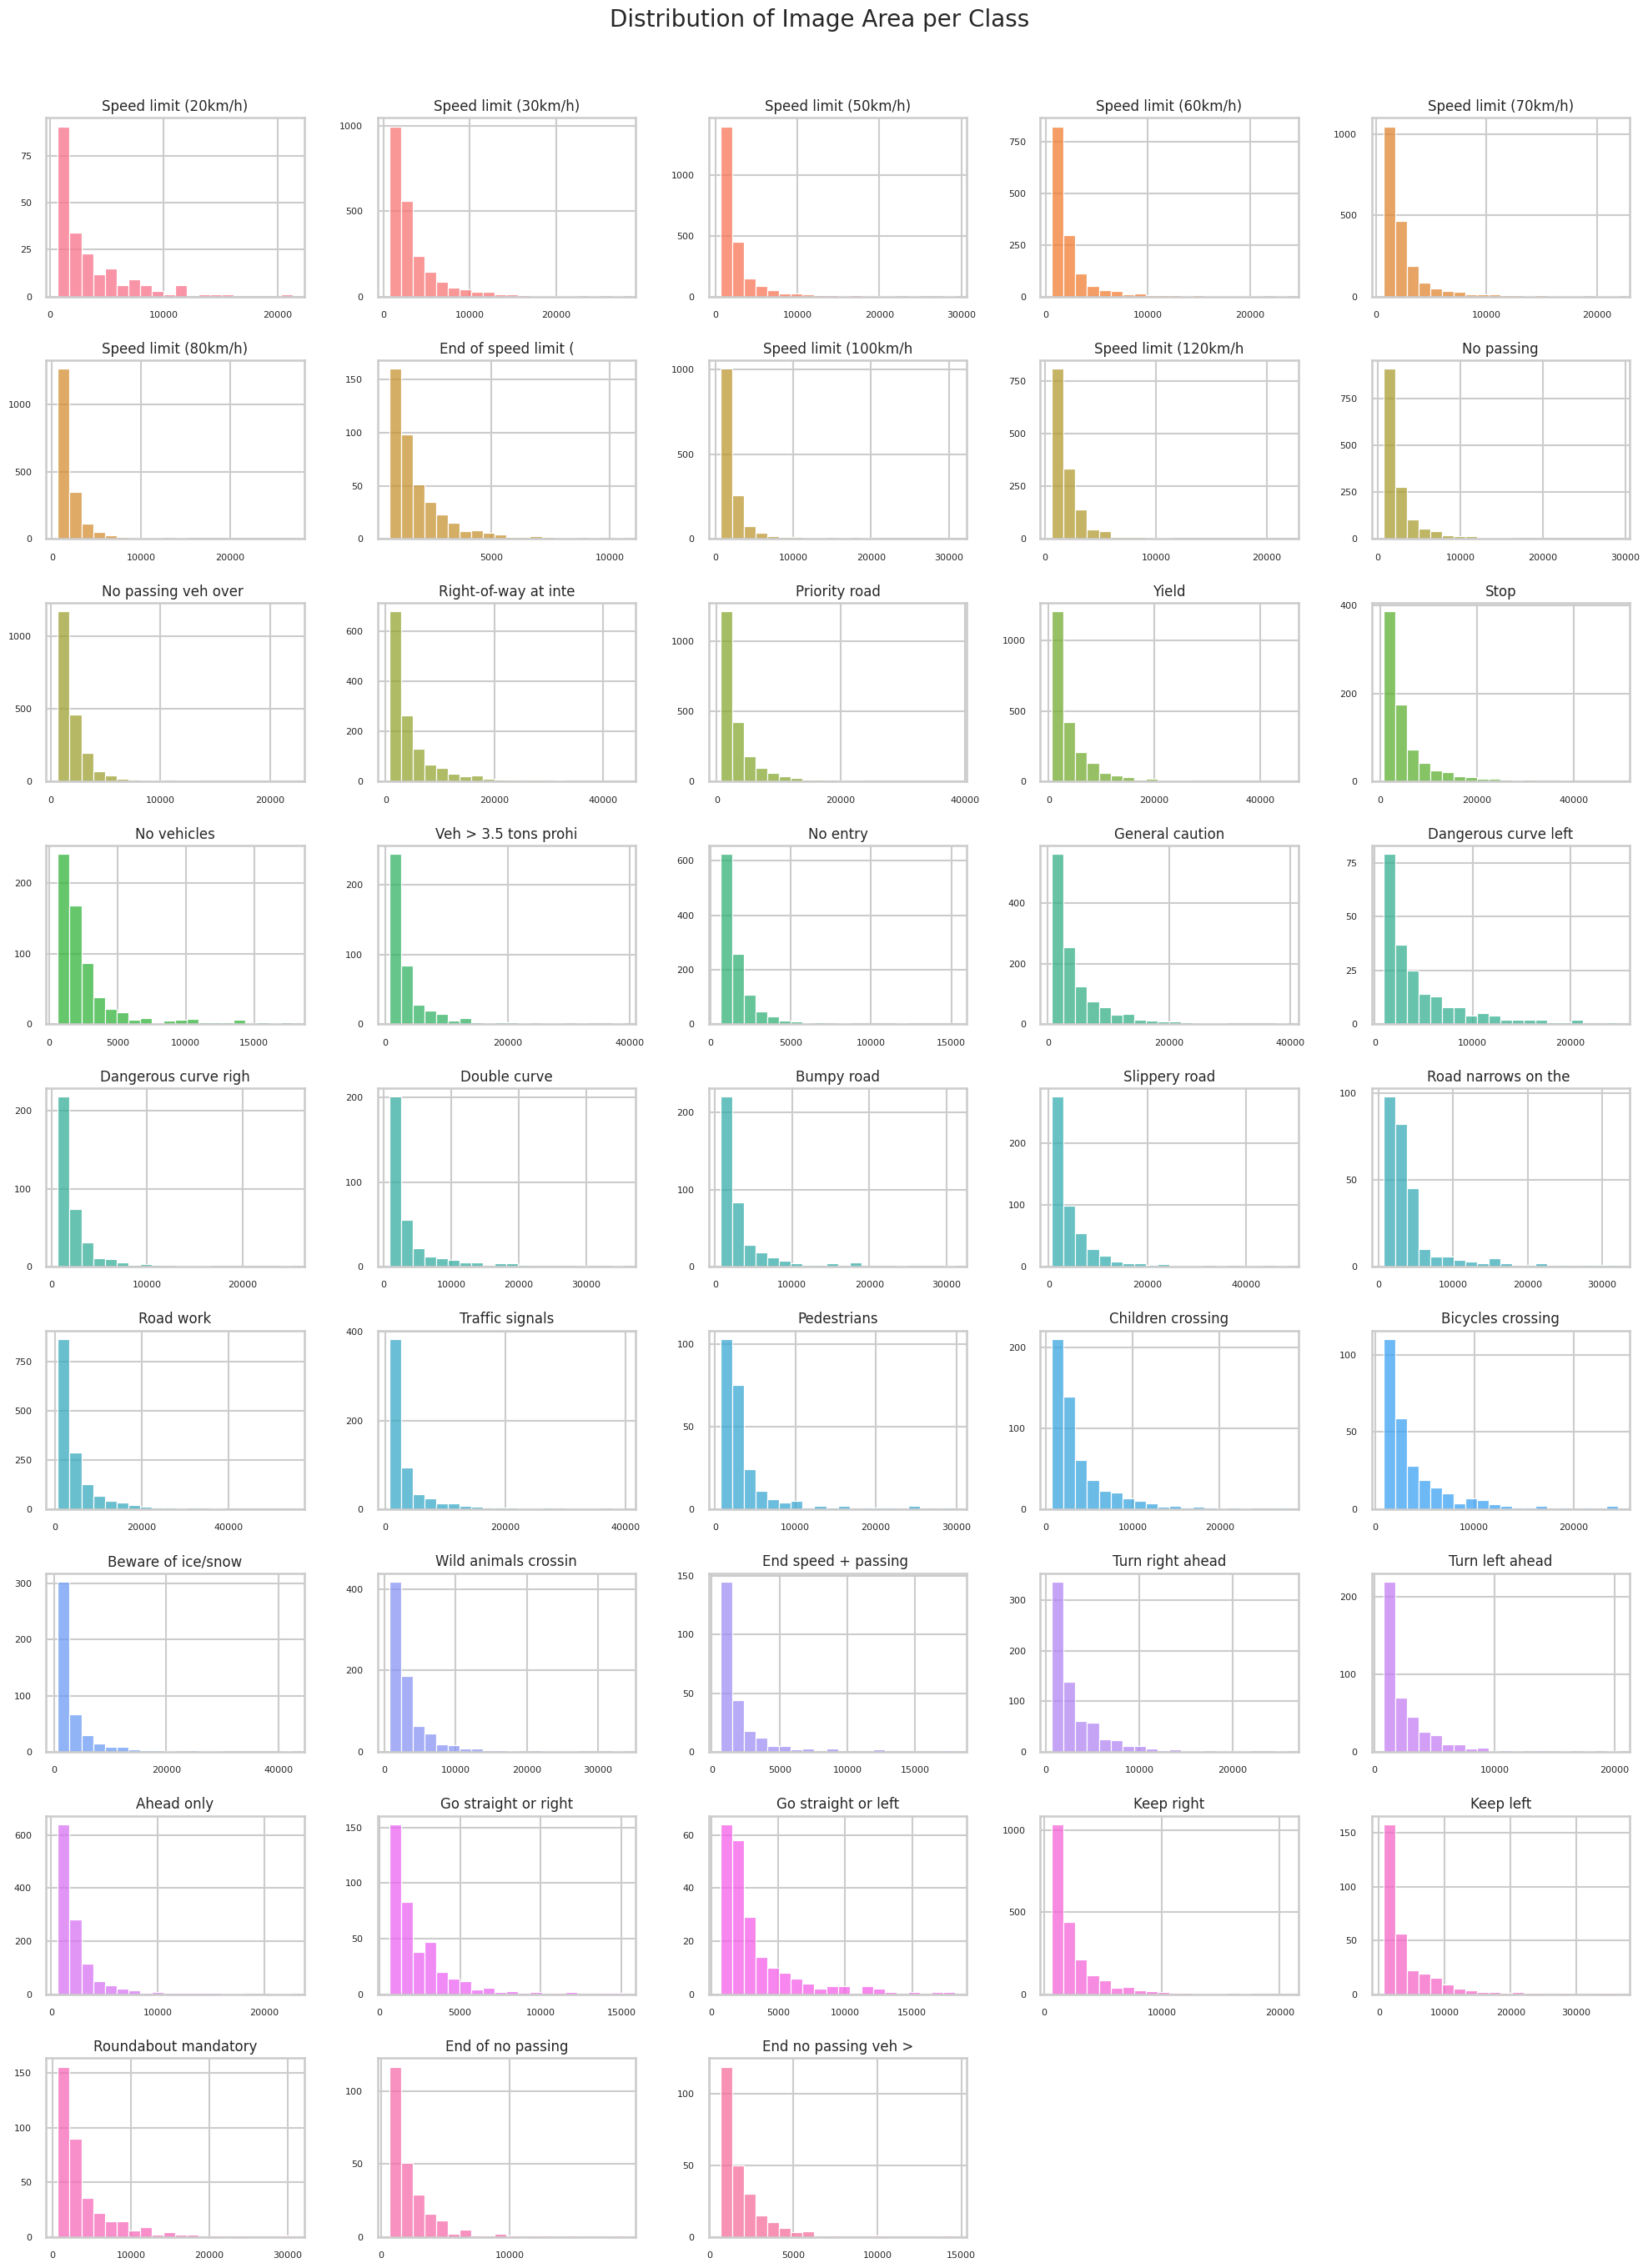

In [235]:
plot_resolution_per_class_grid(data, classes)

In [201]:
data[['Width','Height']].corr()

,Width,Height
Width,1.00000,0.98124
Height,0.98124,1.00000


The correlation between width and height is very high (0.98), indicating a strong positive linear relationship. This confirms that most images have similar width and height values and are therefore approximately square.

In [203]:
stats_resolution = resolution_stats(data, classes)

Classes with the highest mean area

In [204]:
stats_resolution[:5]

,Width_mean,Width_std,Height_mean,Height_std,Area_mean,Area_std,ClassName
ClassId,,,,,,,
14,64.425641,32.710083,66.434615,33.287360,5357.315385,6217.293182,Stop
25,64.822000,33.973005,60.835333,31.093098,4991.518667,6144.061471,Road work
23,65.447059,32.932809,60.152941,29.106676,4890.123529,5818.816435,Slippery road
11,64.037879,32.516819,59.714394,28.510021,4741.790909,5343.855296,Right-of-way at intersection
18,63.525833,30.265095,59.666667,27.672526,4620.864167,4842.294573,General caution


Classes with the lowest mean area

In [205]:
stats_resolution[-5:]

,Width_mean,Width_std,Height_mean,Height_std,Area_mean,Area_std,ClassName
ClassId,,,,,,,
5,42.515054,16.060245,42.823656,16.510452,2083.274194,2094.239589,Speed limit (80km/h)
32,41.004167,16.660403,41.425000,16.438124,1968.908333,2034.883229,End speed + passing limits
42,41.145833,13.875401,41.291667,13.613859,1885.904167,1538.856690,End no passing veh > 3.5 tons
6,40.404762,13.087296,42.126190,13.852816,1881.604762,1413.754647,End of speed limit (80km/h)
17,38.010811,12.198681,40.273874,12.464367,1677.474775,1324.315562,No entry


**1. Width & Height Distribution**

- Right-skewed distributions

- Most images have relatively small dimensions (~30–70 pixels)

- Presence of larger images (long tail)

**2. Width vs Height**

- Strong positive linear relationship

- Points concentrated near the diagonal

**3. Aspect Ratio**

- Centered around 1.0

- Small variation (~0.8–1.2)

**4. Area Distribution**

- Strong right-skew

- Dominance of small areas

- Presence of a small number of large outliers

**5. Per-Class Analysis**

- Similar distribution shapes across classes

- Differences in scale and variability

The dataset contains images with non-uniform spatial resolutions, indicating that image size is not fixed. Most images are relatively small, while a smaller number of large images create a long-tailed distribution. Width and height are strongly correlated, indicating that the majority of images are approximately square. The aspect ratio distribution further confirms that shape distortions are minimal. Although different classes vary in scale, they exhibit similar distribution patterns overall.

# Brightness Distribution Analysis

In [242]:
def compute_brightness_full(data, root):
    brightness = []

    for i in range(len(data)):
        img_path = os.path.join(root, data.iloc[i]['Path'])
        img = cv2.imread(img_path)

        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        brightness.append({
            'ClassId': data.iloc[i]['ClassId'],
            'Brightness': float(np.mean(gray))
        })

    return pd.DataFrame(brightness)

def plot_brightness_with_levels(brightness_df):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    plt.figure(figsize=(10,6))

    sns.histplot(brightness_df['Brightness'], bins=40, kde=True, color="#4C72B0")

    # Thresholds
    plt.axvline(85, color='gray', linestyle='--')
    plt.axvline(170, color='gray', linestyle='--')

    # Compute percentages
    brightness_df = brightness_df.copy()

    brightness_df['BrightnessLevel'] = pd.cut(
        brightness_df['Brightness'],
        bins=[0, 85, 170, 255],
        labels=['Dark', 'Medium', 'Bright']
    )

    percentages = brightness_df['BrightnessLevel'].value_counts(normalize=True) * 100

    # Add percentage labels
    plt.text(20, plt.ylim()[1]*0.8, f"Dark\n{percentages['Dark']:.1f}%", fontsize=12)
    plt.text(100, plt.ylim()[1]*0.8, f"Medium\n{percentages['Medium']:.1f}%", fontsize=12)
    plt.text(200, plt.ylim()[1]*0.8, f"Bright\n{percentages['Bright']:.1f}%", fontsize=12)

    plt.xlabel('Brightness')
    plt.ylabel('Count')
    plt.title('Brightness Distribution with Levels')

    plt.tight_layout()
    plt.show()

def plot_brightness_per_class_grid(brightness_df, classes, n_cols=5):
    class_ids = sorted(brightness_df['ClassId'].unique())
    n_classes = len(class_ids)
    n_rows = int(np.ceil(n_classes / n_cols))

    # Color palette
    palette = sns.color_palette("husl", n_classes)

    plt.figure(figsize=(20, n_rows * 3))

    plt.suptitle('Brightness Distribution per Class', fontsize=20, y=1.01)

    for i, cid in enumerate(class_ids):
        plt.subplot(n_rows, n_cols, i+1)

        subset = brightness_df[brightness_df['ClassId'] == cid]

        sns.histplot(
            subset['Brightness'],
            bins=20,
            kde=False,
            color=palette[i]
        )

        plt.title(classes[cid][:20], fontsize=12)
        plt.xlabel('')
        plt.ylabel('')
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10)

    plt.tight_layout()
    plt.show()

def plot_brightness_boxplot(brightness_df, classes):
    # Add class names
    brightness_df['ClassName'] = brightness_df['ClassId'].apply(lambda x: classes[x])

    plt.figure(figsize=(22,8))

    # Color palette
    palette = sns.color_palette("husl", len(classes))

    sns.boxplot(
        x='ClassName',
        y='Brightness',
        data=brightness_df,
        hue='ClassName',  
        palette=palette
    )

    plt.xticks(rotation=90)

    plt.xlabel('Traffic Sign Class')
    plt.ylabel('Brightness')
    plt.title('Brightness Distribution per Class (Boxplot)')

    plt.tight_layout()
    plt.show()

def brightness_statistics(brightness_df, classes):
    stats = brightness_df.groupby('ClassId')['Brightness'].agg([
        'mean', 'std', 'min', 'max', 'median'
    ])

    stats['ClassName'] = [classes[i] for i in stats.index]

    return stats.sort_values('mean', ascending=False)



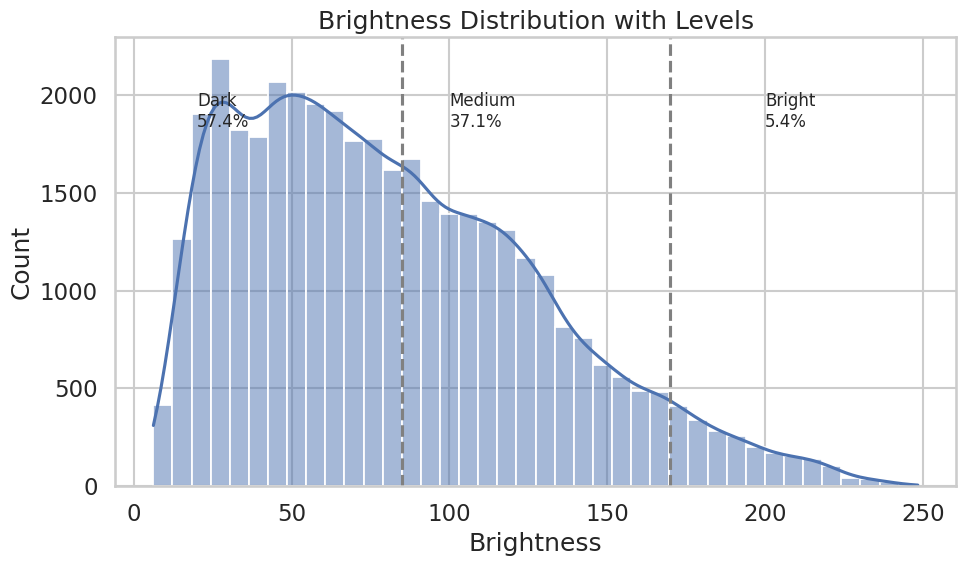

In [221]:
root = "/home/olena-yazykova/computer_vision/lesson_13/data/GTSRB"

brightness_df = compute_brightness_full(data, root)

plot_brightness_with_levels(brightness_df)

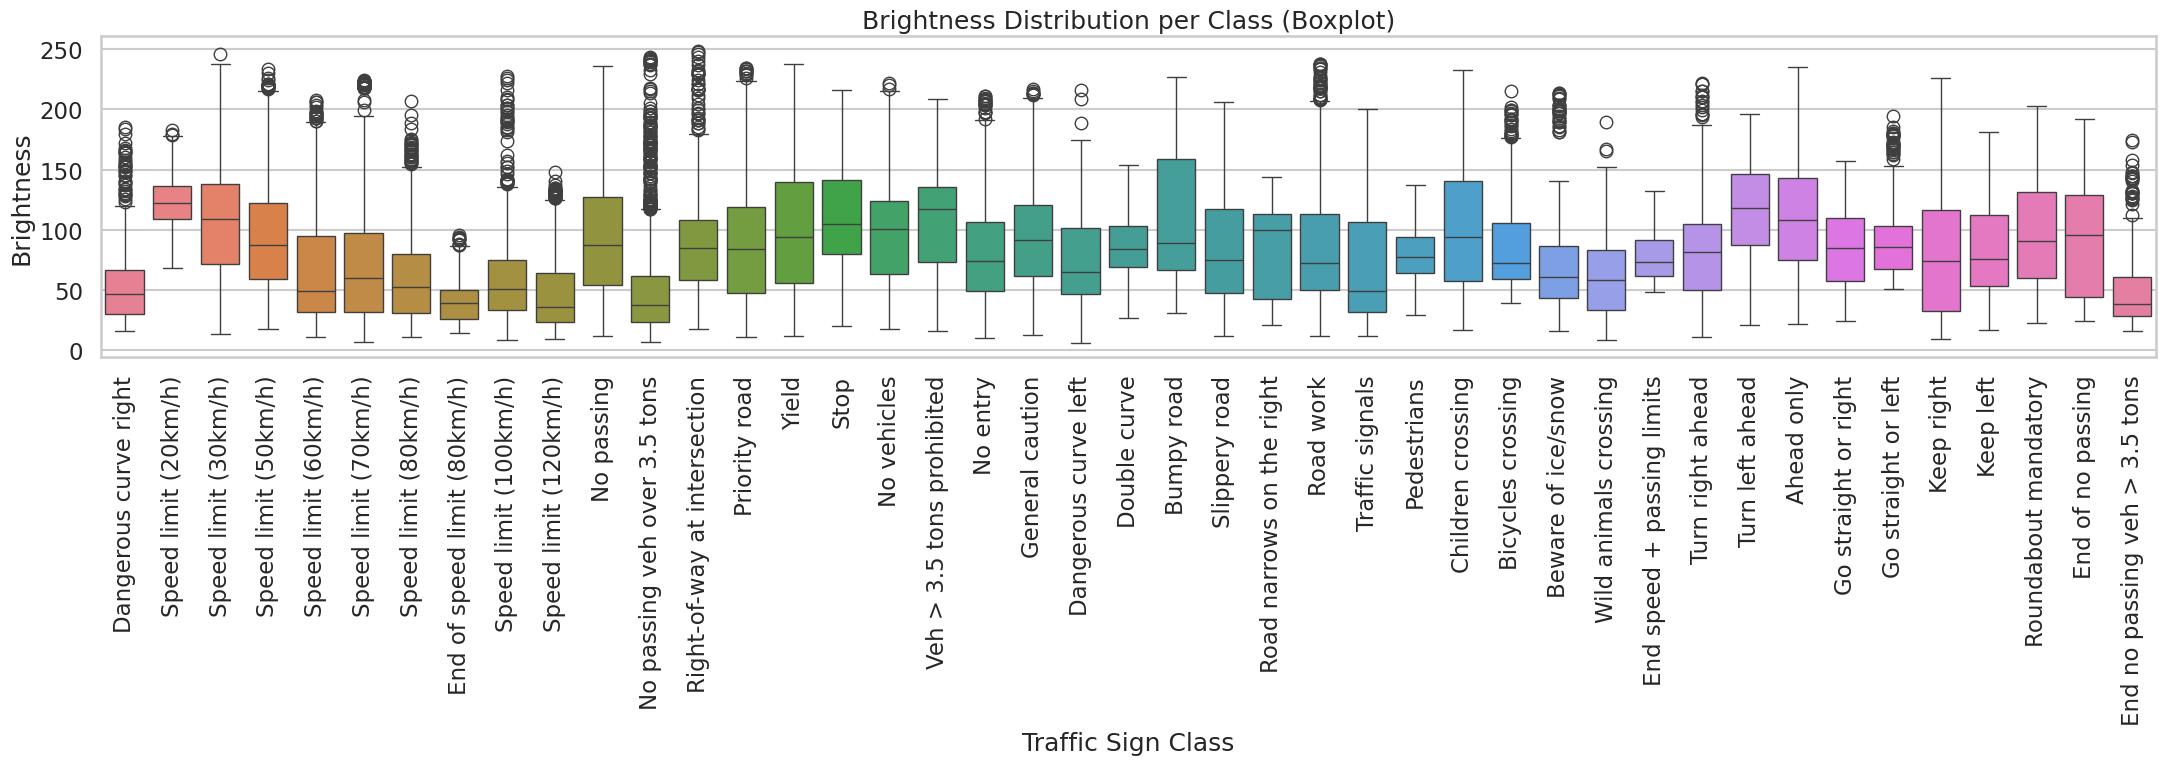

In [251]:
plot_brightness_boxplot(brightness_df, classes)

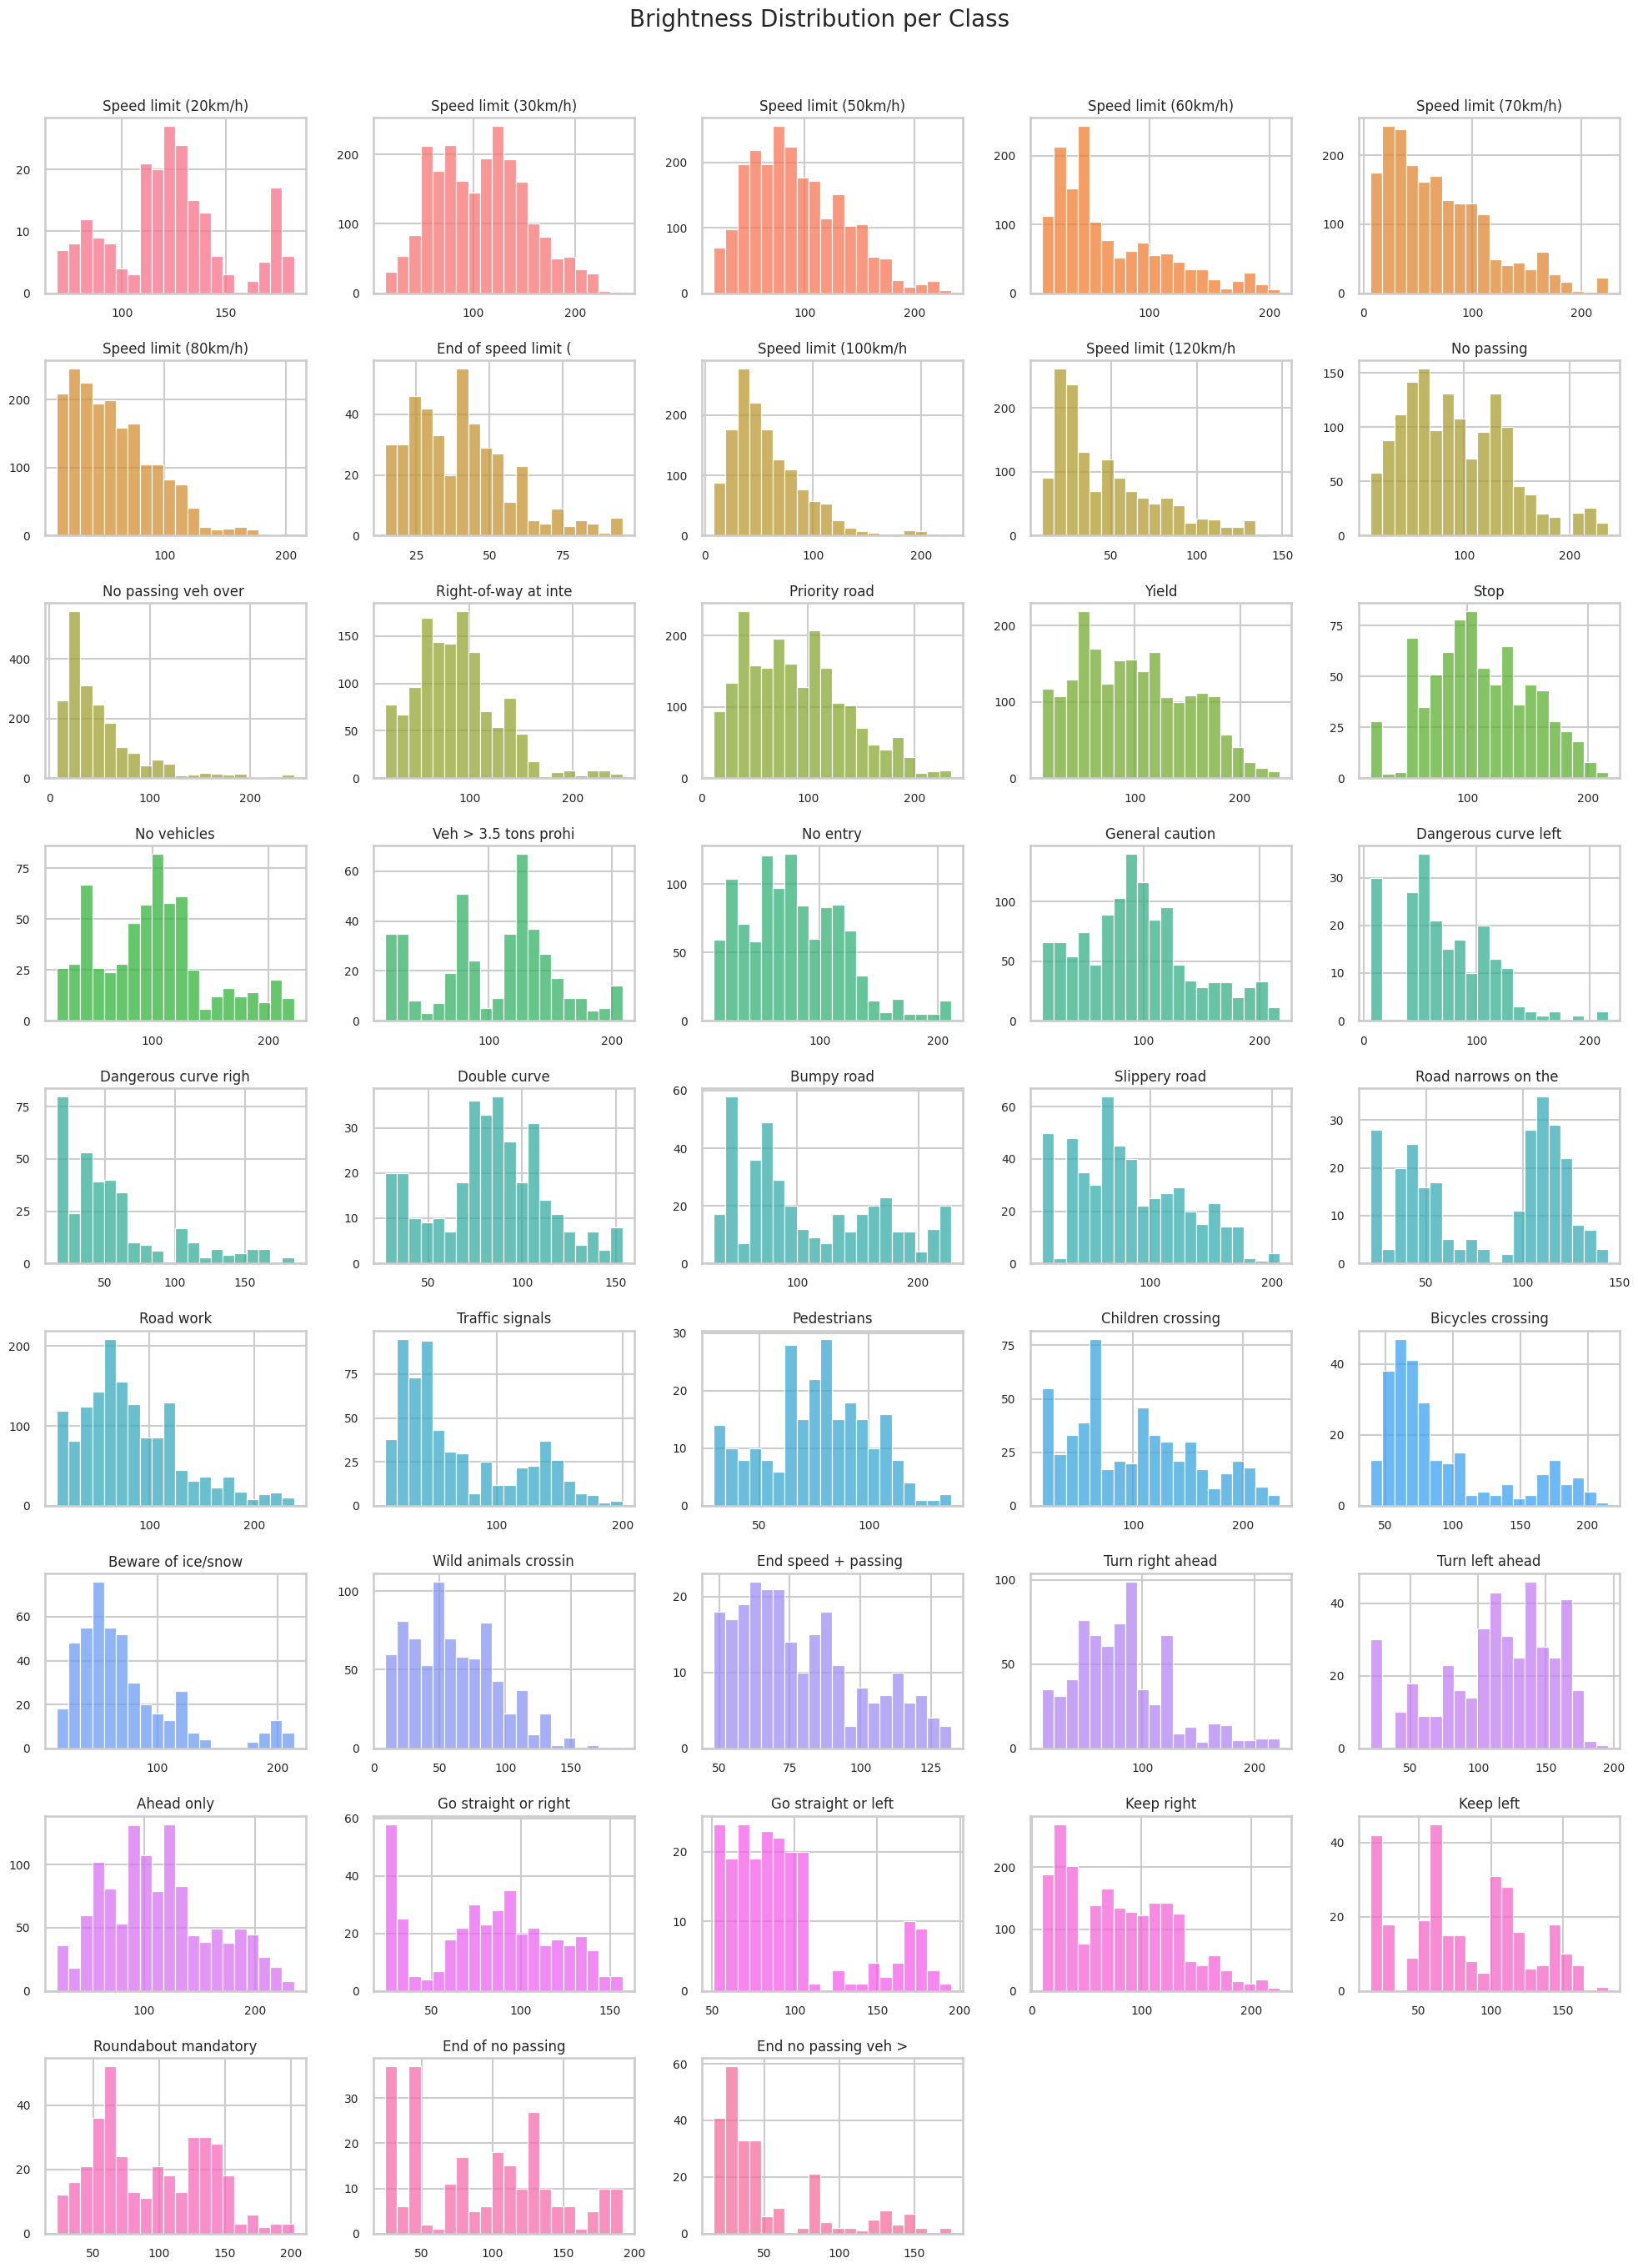

In [243]:
plot_brightness_per_class_grid(brightness_df, classes)

In [244]:
stats_brightness = brightness_statistics(brightness_df, classes)

Classes with the highest mean brightness

In [245]:
stats_brightness[:5]

,mean,std,min,max,median,ClassName
ClassId,,,,,,
0,122.700563,28.338500,68.495495,182.707017,122.602972,Speed limit (20km/h)
35,113.527621,48.464590,21.515344,235.249703,108.080751,Ahead only
34,113.344344,42.309412,20.695756,195.704473,117.839786,Turn left ahead
14,110.130700,41.985240,19.924695,216.282051,105.008911,Stop
22,109.747361,57.106617,31.075000,226.983410,89.226987,Bumpy road


Classes with the lowest mean brightness

In [250]:
stats_brightness[-5:]

,mean,std,min,max,median,ClassName
ClassId,,,,,,
20,57.361867,40.118967,15.753567,185.156415,46.500415,Dangerous curve right
42,52.030146,37.870381,16.039039,174.283476,37.951393,End no passing veh > 3.5 tons
10,50.392712,40.351524,7.222369,243.237681,37.660144,No passing veh over 3.5 tons
8,46.908378,29.690514,9.559290,148.238739,36.028822,Speed limit (120km/h)
6,40.250423,17.240830,14.340699,95.314638,39.515731,End of speed limit (80km/h)


**1. Global Brightness Distribution**

- Right-skewed distribution

- Majority of images fall into low and medium brightness ranges

- Small proportion of highly bright images

**2. Brightness Levels**

- Approximately 57% of images are dark

- Around 37% have medium brightness

- Only about 5% are highly bright

**3. Per-Class Brightness Distribution**

- Similar distribution shapes across classes

- Most classes show dominance of low-to-medium brightness values

- Variability exists between classes in median brightness and spread

The brightness distribution is dominated by dark and moderately lit images, with only a small fraction of highly bright samples. This indicates that most images were captured under low to moderate lighting conditions. While brightness distributions are similar across classes, some variation in intensity levels suggests differences in environmental or acquisition conditions.

# Conclusions and Recommendations for Data Preprocessing

The dataset is not balanced, as the number of samples per class varies significantly. This imbalance may negatively affect model performance, as models tend to be biased toward more frequent classes and perform worse on under-represented ones.

Additionally, the dataset contains images with varying spatial resolutions and brightness levels. Most images are relatively small and approximately square, but their sizes are not consistent. Therefore, it is important to resize all images to a fixed resolution before training.

The brightness analysis shows that the dataset is dominated by dark and moderately lit images, which may introduce bias toward low-light conditions. Applying brightness normalization or data augmentation can help improve model robustness.

To address these issues, it is recommended to:

- **Balance the dataset** (e.g., using class weighting, oversampling, or augmentation)

- **Resize images to a consistent input size**

- **Apply brightness normalization or augmentation techniques**